In [102]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path
from skimage.filters import frangi, threshold_otsu
from skimage.morphology import closing, disk, remove_small_objects
from skimage.exposure import equalize_adapthist
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix

DATA_DIR = Path.cwd() / "data"
ORIGINAL_DIR = DATA_DIR / "original"
LABELS_DIR = DATA_DIR / "labels"


In [103]:
def split_channels(image: np.ndarray):
    return image[:, :, 0], image[:, :, 1], image[:, :, 2]

In [104]:
def load_image(path: Path) -> np.ndarray:
    return np.array(Image.open(path))


def load_label(path: Path) -> np.ndarray:
    lbl = np.array(Image.open(path))
    return (lbl > 0).astype(np.uint8)

def display_images(*images, titles=None, cmap="gray", figsize_per_image=(4, 4)):
    n = len(images)
    if titles is None:
        titles = [f"Image {i + 1}" for i in range(n)]
    elif len(titles) != n:
        raise ValueError(f"{n} images but {len(titles)} titles")

    _, axes = plt.subplots(1, n, figsize=(figsize_per_image[0] * n, figsize_per_image[1]))
    if n == 1:
        axes = [axes]
    for ax, img, title in zip(axes, images, titles):
        ax.imshow(img, cmap=cmap)
        ax.set_title(title)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

In [ ]:
def evaluate(pred: np.ndarray, gold: np.ndarray) -> dict:
    """Compute evaluation metrics between prediction and gold standard."""
    p_flat = pred.ravel()
    g_flat = gold.ravel()

    matrix = confusion_matrix(g_flat, p_flat).ravel()

    return {
        "accuracy": accuracy_score(g_flat, p_flat),
        "f1": f1_score(g_flat, p_flat, zero_division=0),
        "tn": int(matrix[0]),
        "fp": int(matrix[1]),
        "fn": int(matrix[2]),
        "tp": int(matrix[3]),
    }

In [106]:
import cv2

def apply_mask(data: np.ndarray, mask: np.ndarray) -> np.ndarray:
    return data * mask



def create_retinal_mask(image_array: np.ndarray) -> np.ndarray:
    gray = cv2.cvtColor(image_array, cv2.COLOR_BGR2GRAY)

    blurred = cv2.medianBlur(gray, 11)
    _, thresh = cv2.threshold(blurred, 45, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    if not contours:
        return np.zeros_like(gray, dtype=bool)
    largest_contour = max(contours, key=cv2.contourArea)

    mask_8u = np.zeros_like(gray)
    cv2.drawContours(mask_8u, [largest_contour], -1, 255, thickness=cv2.FILLED)

    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    mask_8u = cv2.erode(mask_8u, kernel, iterations=1)

    return mask_8u > 0


In [107]:
import cv2

def apply_clahe(green: np.ndarray, mask: np.ndarray, clip_limit: float = 0.015, nbins: int = 256, kernel = 128) -> np.ndarray:
    normalized = green.astype(float) / 255.0
    normalized[~mask] = 0
    enhanced = equalize_adapthist(normalized, kernel_size=kernel, clip_limit=clip_limit, nbins=nbins)
    enhanced[~mask] = 0
    return enhanced


def preprocess_image(image, mask, *, clip_limit = 0.015, nbins = 256, kernel = 128, gauss: tuple[int, int] = (51, 51)):
    if isinstance(image, (str, Path)):
        img = np.array(Image.open(image)).astype(np.uint8)
    else:
        img = image.astype(np.uint8)

    img = cv2.medianBlur(img, 5)

    bg_map = cv2.GaussianBlur(img, gauss, 0)
    flat_bg = cv2.subtract(bg_map, img)
    flat_bg = np.clip(flat_bg, 0, 255).astype(np.uint8)

    flat_bg = cv2.medianBlur(flat_bg, 5)
    
    clahe = apply_clahe(flat_bg, mask=mask, clip_limit=clip_limit, nbins=nbins, kernel=kernel)
    return clahe


In [108]:
def frangi_vesselness(image: np.ndarray, sigmas: tuple = (1, 2, 3), alpha: float = 0.5, beta: float = 0.5, gamma: float | None = None, scale_step=2, black_ridges: bool = True) -> np.ndarray:
    return frangi(image, sigmas=sigmas, alpha=alpha, beta=beta, gamma=gamma, black_ridges=black_ridges, scale_step=scale_step)


/tmp/ipykernel_20348/764529501.py:15: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  binary = remove_small_objects(binary, min_size=40)


Evaluation Metrics for im0001.ppm:
Accuracy: 0.9012
F1-Score: 0.4935


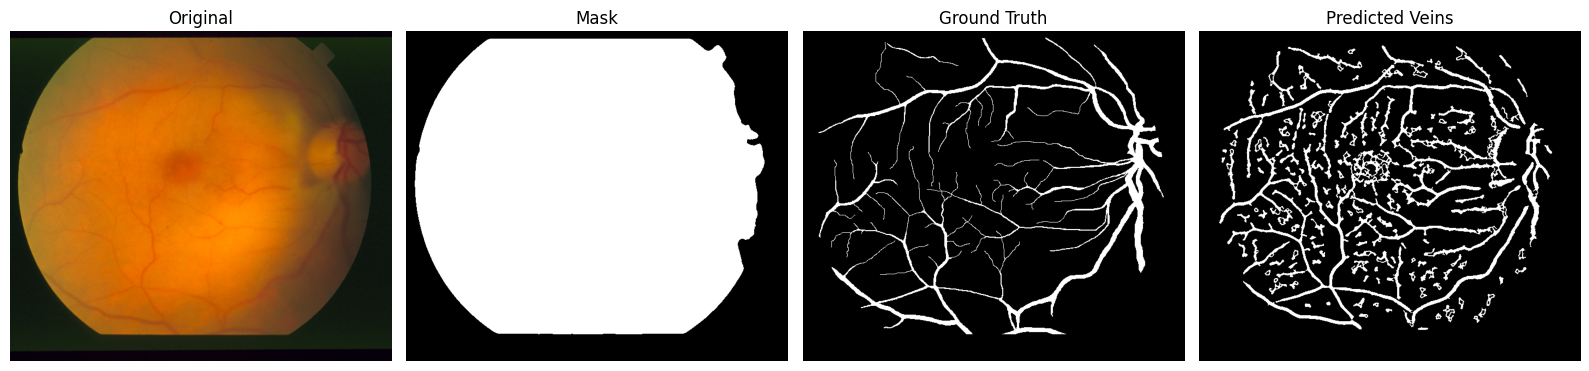

In [109]:
def extract_veins(image: np.ndarray, sigmas: tuple = (0.5, 1, 1.5, 2, 2.5, 3), clip_limit: float = 0.015, alpha: float = 0.5, beta: float = 0.5, gamma: float | None = None) -> np.ndarray:
    _, green, _ = split_channels(image)
    
    fg_mask = create_retinal_mask(image)

    enhanced = preprocess_image(green, fg_mask, clip_limit=clip_limit, kernel=128, gauss=(51, 51))
    
    vesselness = frangi_vesselness(enhanced, sigmas=sigmas, alpha=alpha, beta=beta, gamma=gamma, black_ridges=False, scale_step=None)
    vesselness_masked = apply_mask(vesselness, fg_mask)

    thresh = threshold_otsu(vesselness_masked[fg_mask])
    binary = vesselness_masked > thresh * 0.32

    binary = closing(binary, disk(1))
    binary = remove_small_objects(binary, min_size=40)

    return binary.astype(np.uint8)


img = load_image(ORIGINAL_DIR / "im0004.ppm")
orig = load_label(LABELS_DIR / "im0004.vk.ppm")

r = extract_veins(img)

mask = create_retinal_mask(img)
mask_img = np.ones(img.shape)
mask_img[~mask] = 0

metrics = evaluate(r, orig)
print("Evaluation Metrics for im0001.ppm:")
print(f"Accuracy: {metrics['accuracy']:.4f}")
print(f"F1-Score: {metrics['f1']:.4f}")

# Display results
display_images(img, mask_img, orig, r, titles=["Original", "Mask", "Ground Truth", "Predicted Veins"])


/tmp/ipykernel_20348/764529501.py:15: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  binary = remove_small_objects(binary, min_size=40)


--- Images for im0240.ppm ---


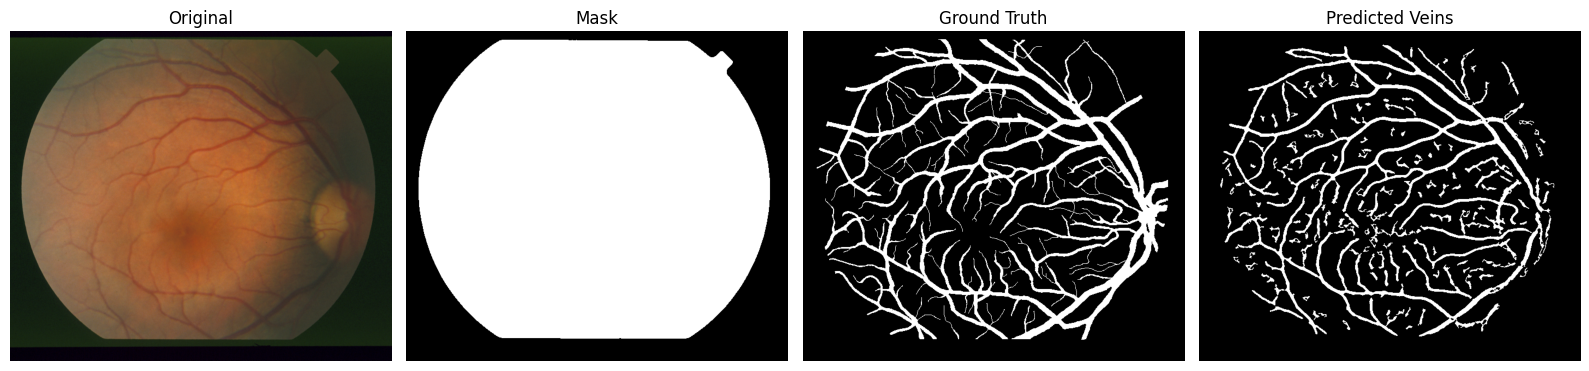

/tmp/ipykernel_20348/764529501.py:15: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  binary = remove_small_objects(binary, min_size=40)


--- Images for im0255.ppm ---


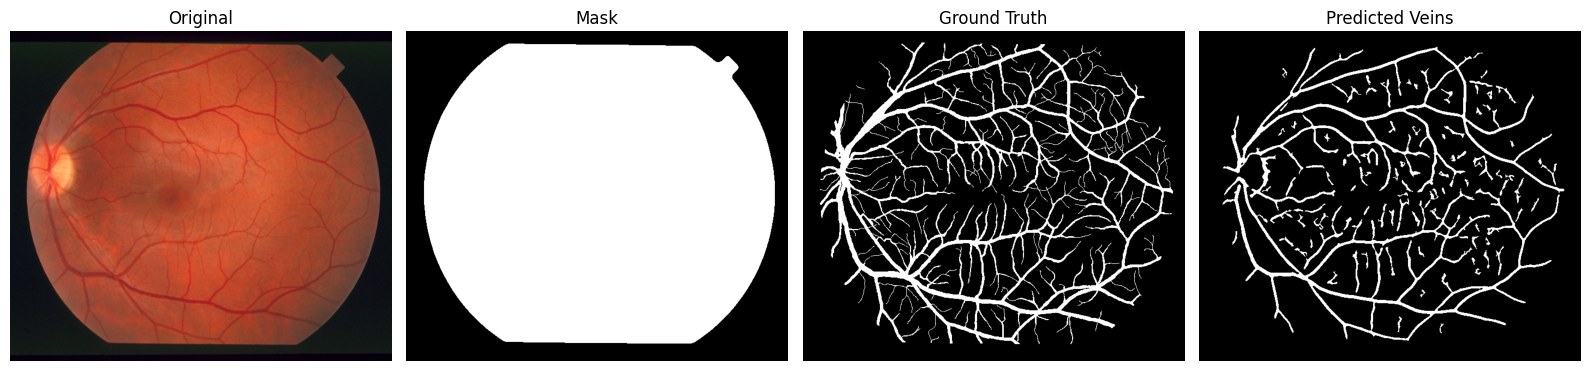

/tmp/ipykernel_20348/764529501.py:15: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  binary = remove_small_objects(binary, min_size=40)


--- Images for im0291.ppm ---


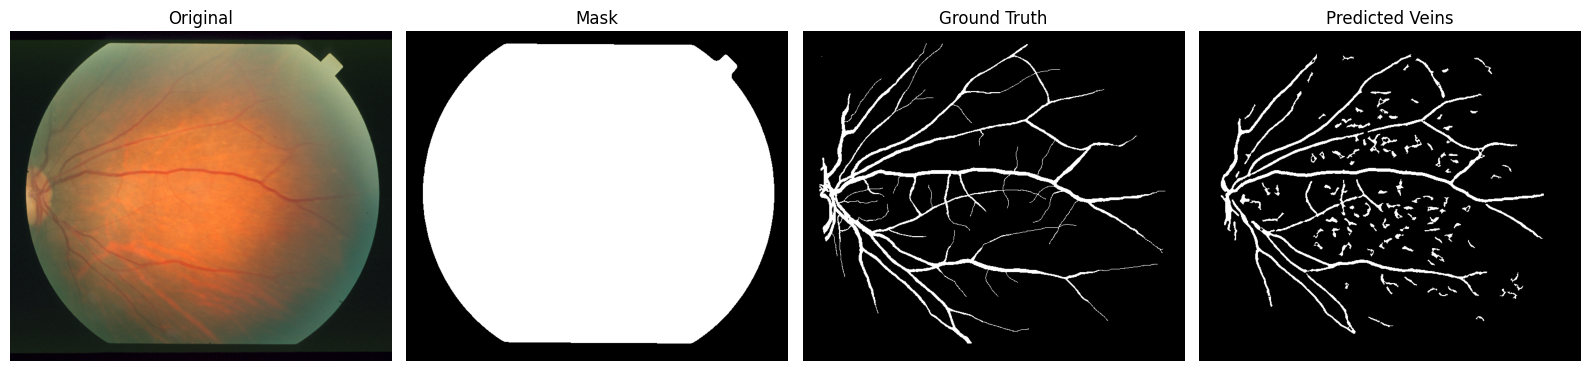

/tmp/ipykernel_20348/764529501.py:15: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  binary = remove_small_objects(binary, min_size=40)


--- Images for im0319.ppm ---


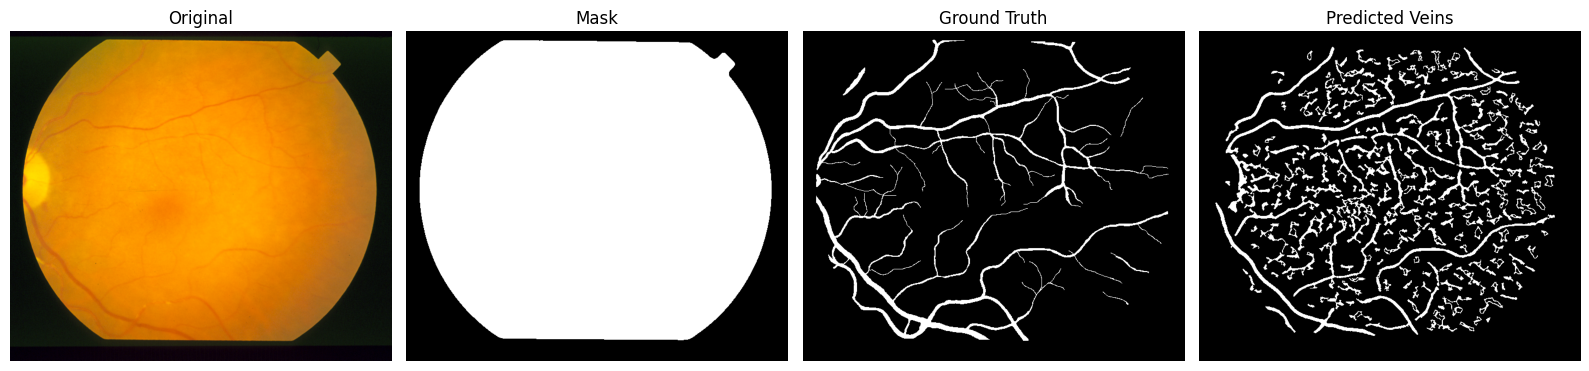

/tmp/ipykernel_20348/764529501.py:15: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  binary = remove_small_objects(binary, min_size=40)


--- Images for im0324.ppm ---


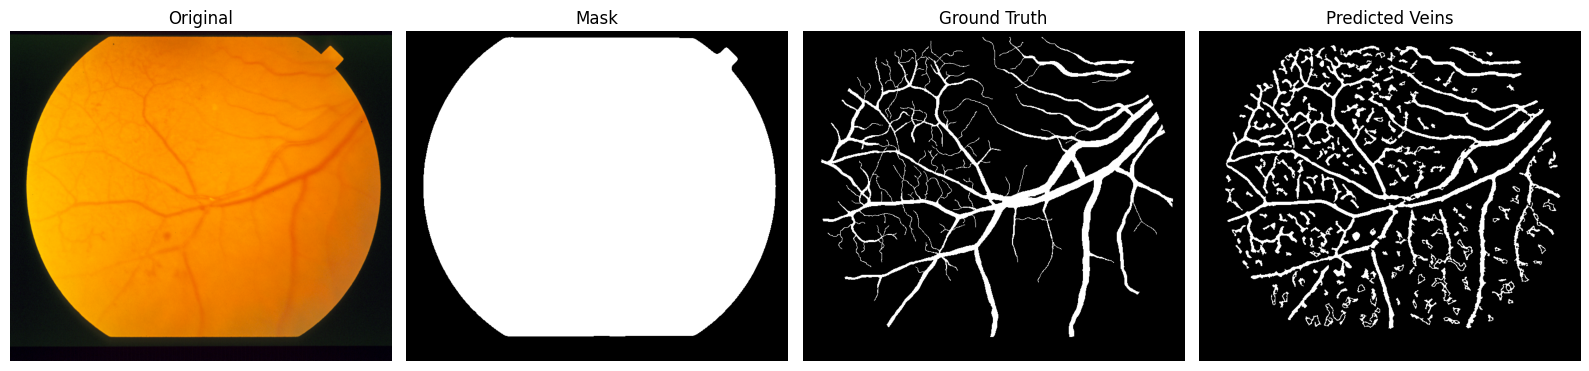


--- Overall Evaluation Stats ---
     Image  accuracy       f1     tn    tp    fn    fp
im0240.ppm  0.913041 0.678398 347831 38842 25742 11085
im0255.ppm  0.932756 0.703817 361186 33836 21698  6780
im0291.ppm  0.960796 0.686007 388760 18137  8013  8590
im0319.ppm  0.897995 0.448042 362768 17533  9048 34151
im0324.ppm  0.904791 0.582698 355028 28151 14058 26263


In [111]:
import pandas as pd

# 1. Collect metrics and display images in a loop
all_metrics = []
all_images = sorted(list(ORIGINAL_DIR.glob("*.ppm")))

for img_path in all_images[-5:]:
    file_name = img_path.name
    label_path = LABELS_DIR / file_name.replace(".ppm", ".vk.ppm")

    if not label_path.exists():
        continue

    # Load and process
    img = load_image(img_path)
    orig = load_label(label_path)
    r = extract_veins(img)

    mask = create_retinal_mask(img)
    mask_img = np.ones(img.shape)
    mask_img[~mask] = 0

    # Evaluate and store metrics
    metrics = evaluate(r, orig)
    metrics["Image"] = file_name
    all_metrics.append(metrics)

    # Display images
    print(f"--- Images for {file_name} ---")
    display_images(img, mask_img, orig, r, titles=["Original", "Mask", "Ground Truth", "Predicted Veins"],)

# 2. Create and display pandas DataFrame
df = pd.DataFrame(all_metrics)
df = df[["Image", "accuracy", "f1", "tn", "tp", "fn", "fp"]]  # Reorder columns

print("\n--- Overall Evaluation Stats ---")
print(df.to_string(index=False))